In [1]:
import duckdb
from pathlib import Path

csv_path = Path(r"D:\2026\MockProject_062026_NhomAI\data\randhrs_output.csv")
out_path = Path(r"D:\2026\MockProject_062026_NhomAI\data\filtered_5core.csv")

keep_cols = [
    # Định danh & Nhân khẩu học
    'HHIDPN', 'RAGENDER', 'R16AGEY_M',
    
    # Core A: Khó khăn ADL & IADL chi tiết
    'R16DRESS', 'R16BATH', 'R16EAT', 'R16BED', 'R16TOILT', 'R16WALK1',
    'R16PHONE', 'R16MONEY', 'R16MEDS', 'R16MEALS', 'R16SHOP',
    
    # Core B & C: Thần kinh & Lâm sàng nguy kịch
    'R16WANDER', 'R16LOST', 'R16HALUC', 'R16DEMEN', 'R16ALZHE', 
    'REBEDRID', 'R16STROK', 'R16SDAPNEA', 'R16TIMWLK', 'R16BALSEMI', 'R16BALFUL',
    
    # Core D: Tâm trạng (Trầm cảm chi tiết)
    'R16DEPRES', 'R16EFFORT', 'R16SLEEPR', 'R16FLONE', 'R16FSAD', 'R16GOING', 'R16WHAPPY', 'R16ENLIFE',
    
    # Biến nền tổng hợp thực tế có trong file để trích xuất nhãn
    'R16ADL5A', 'R16IADL5A', 'R16CESD',
    'H16ATOTW', 'H16ITOT', 'H16INPOV', 'R16IEARN', 'R16IPEN', 'R16ISRET', 'R16OOPMD'
]

schema_df = duckdb.sql(
    f"DESCRIBE SELECT * FROM read_csv_auto('{csv_path.as_posix()}', header=true)"
).df()
available_cols = schema_df['column_name'].tolist()
existing_cols = [col for col in keep_cols if col in available_cols]
missing_cols = [col for col in keep_cols if col not in available_cols]

if not existing_cols:
    raise ValueError('Không tìm thấy cột nào trong danh sách keep_cols.')

columns_sql = ",\n    ".join(existing_cols)
query = f"""
SELECT
    {columns_sql}
FROM read_csv_auto('{csv_path.as_posix()}', header=true)
"""

# Tạo CSV mới
copy_sql = f"""
COPY (
{query}
) TO '{out_path.as_posix()}' (HEADER, DELIMITER ',')
"""
duckdb.sql(copy_sql)

# Tạo DataFrame để xem nhanh trong notebook

df_filtered = duckdb.sql(query).df()

print('Available columns found:', len(available_cols))
print('Kept columns:', existing_cols)
print('Missing columns:', missing_cols)
print('Filtered shape:', df_filtered.shape)
print('Saved to:', out_path)

Available columns found: 19880
Kept columns: ['HHIDPN', 'RAGENDER', 'R16AGEY_M', 'R16DRESS', 'R16BATH', 'R16EAT', 'R16BED', 'R16TOILT', 'R16WALK1', 'R16PHONE', 'R16MONEY', 'R16MEDS', 'R16MEALS', 'R16SHOP', 'R16WANDER', 'R16LOST', 'R16HALUC', 'R16DEMEN', 'R16ALZHE', 'REBEDRID', 'R16STROK', 'R16SDAPNEA', 'R16TIMWLK', 'R16BALSEMI', 'R16BALFUL', 'R16DEPRES', 'R16EFFORT', 'R16SLEEPR', 'R16FLONE', 'R16FSAD', 'R16GOING', 'R16WHAPPY', 'R16ENLIFE', 'R16ADL5A', 'R16IADL5A', 'R16CESD', 'H16ATOTW', 'H16ITOT', 'H16INPOV', 'R16IEARN', 'R16IPEN', 'R16ISRET', 'R16OOPMD']
Missing columns: []
Filtered shape: (45234, 43)
Saved to: D:\2026\MockProject_062026_NhomAI\data\filtered_5core.csv


In [2]:
import pandas as pd
from pathlib import Path

csv_path = Path(r"D:\2026\MockProject_062026_NhomAI\data\filtered_5core.csv")

df = pd.read_csv(csv_path, low_memory=False)
print('Shape:', df.shape)
df.head(10)

Shape: (45234, 43)


,HHIDPN,RAGENDER,R16AGEY_M,R16DRESS,R16BATH,R16EAT,R16BED,R16TOILT,R16WALK1,R16PHONE,...,R16ADL5A,R16IADL5A,R16CESD,H16ATOTW,H16ITOT,H16INPOV,R16IEARN,R16IPEN,R16ISRET,R16OOPMD
0,1010.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2010.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3010.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3020.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,10001010.0,1.0,83.0,0.0,NaN,NaN,NaN,NaN,0.0,0.0,...,0.0,0.0,1.0,1.000300e+06,8400.000000,1.0,0.0,0.0,8400.0,0.0
5,10003020.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,10003030.0,2.0,66.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,2.0,5.241210e+06,13000.000000,0.0,0.0,0.0,0.0,0.0
7,10004010.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,10004040.0,2.0,77.0,NaN,NaN,NaN,NaN,NaN,0.0,0.0,...,0.0,0.0,0.0,1.845874e+06,72695.146291,0.0,0.0,0.0,24000.0,3880.0
9,10013010.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
import pandas as pd
import numpy as np

output_file = r"D:\2026\MockProject_062026_NhomAI\data\filtered_5core_clean.csv"

# 1. Đọc tệp dữ liệu đã lọc (Giả sử df đã được định nghĩa từ bước đọc file)
print(f"Kích thước tệp gốc: {df.shape}")

# 2. XỬ LÝ HAO HỤT MẪU (ATTRITION)
# Loại bỏ ngay những dòng không có bất kỳ phản hồi ADL nào ở Wave 16 (2022)
adl_core_cols = ['R16DRESS', 'R16BATH', 'R16EAT', 'R16BED', 'R16TOILT']
df_clean = df.dropna(subset=adl_core_cols, how='all').copy()
print(f"[*] Kích thước sau khi lọc bỏ đối tượng không tham gia Wave 16: {df_clean.shape}")

# 3. PHÂN TÁCH VÀ XỬ LÝ MISSING VALUE THEO BẢN CHẤT BIẾN

# Bước 3.1: Định nghĩa danh sách các biến Phân loại (Categorical)
categorical_features = adl_core_cols + [
    'R16WALK1', 'R16PHONE', 'R16MONEY', 'R16MEDS', 'R16MEALS', 'R16SHOP',
    'R16WANDER', 'R16LOST', 'R16HALUC', 'R16DEMEN', 'R16ALZHE',
    'REBEDRID', 'R16STROK', 'R16SDAPNEA', 'R16BALSEMI', 'R16BALFUL',
    'R16DEPRES', 'R16EFFORT', 'R16SLEEPR', 'R16FLONE', 'R16FSAD', 'R16GOING', 'R16WHAPPY', 'R16ENLIFE',
    'RAGENDER', 
    'H16INPOV' # Thêm biến cờ nghèo đói (Poverty threshold flag)
]

# Thực thi điền khuyết bằng MODE (Yếu vị)
for col in categorical_features:
    if col in df_clean.columns:
        if df_clean[col].isnull().sum() > 0:
            # Tính toán mode của cột
            col_mode = df_clean[col].mode()
            
            # KIỂM TRA: Nếu cột bị trống 100% (Series rỗng), mặc định điền giá trị 0
            if col_mode.empty:
                mode_value = 0
            else:
                mode_value = col_mode[0]
                
            df_clean[col] = df_clean[col].fillna(mode_value)

# Bước 3.2: Định nghĩa danh sách các biến Số liên tục (Continuous)
continuous_features = [
    'R16AGEY_M', 'R16TIMWLK', 'R16ADL5A', 'R16IADL5A', 'R16CESD',
    'H16ATOTW', 'H16ITOT', 'R16IEARN', 'R16IPEN', 'R16ISRET', 'R16OOPMD' # Thêm các biến tài chính
]

# Thực thi điền khuyết bằng MEDIAN (Trung vị)
for col in continuous_features:
    if col in df_clean.columns:
        if df_clean[col].isnull().sum() > 0:
            median_value = df_clean[col].median()
            # Nếu toàn bộ cột là NaN, điền 0
            if pd.isna(median_value):
                median_value = 0
            df_clean[col] = df_clean[col].fillna(median_value)

# 4. KIỂM TRA TOÀN VẸN DỮ LIỆU (INTEGRITY CHECK)
remaining_missing = df_clean.isnull().sum().sum()
print(f"[*] Tổng số ô khuyết còn lại sau xử lý: {remaining_missing}")
assert remaining_missing == 0, "[LỖI] Vẫn còn dữ liệu khuyết thiếu chưa được làm sạch!"

# 5. TIẾN HÀNH ENGINE NHÃN DỰ ĐOÁN (CARE_LEVEL) SAU KHI DỮ LIỆU ĐÃ SẠCH 100%
print("[*] Đang thực thi gán nhãn Care_Level hệ 5 Core...")
# Thiết lập điều kiện gán nhãn hệ 3 lớp mới (Gộp lớp 2 và lớp 3 cũ)
conditions = [
    # Lớp 2 mới: Chăm sóc đặc biệt (Bao gồm cả nguy kịch thể chất lẫn hành vi thần kinh nặng)
    (df_clean['R16ADL5A'] >= 3) | (df_clean['REBEDRID'] == 1) | \
    (df_clean['R16WANDER'] == 1) | (df_clean['R16DEMEN'] == 1) | (df_clean['R16ALZHE'] == 1) | (df_clean['R16HALUC'] == 1),
    
    # Lớp 1: Khó khăn thể chất nhẹ hoặc gặp triệu chứng trầm cảm lâm sàng
    (df_clean['R16ADL5A'] > 0) | (df_clean['R16IADL5A'] > 0) | (df_clean['R16CESD'] >= 4)
]
choices = [2, 1]

# Thực thi tạo nhãn (Mặc định còn lại là Lớp 0: Độc lập/An toàn)
df_clean['Care_Level'] = np.select(conditions, choices, default=0)

# 6. LƯU TỆP SẠCH HOÀN CHỈNH
df_clean.to_csv(output_file, index=False)
print(f"[THÀNH CÔNG] Dữ liệu sạch đã sẵn sàng tại: {output_file}")
print("\nPhân phối phân lớp Care_Level thu được phục vụ Modeling:")
print(df_clean['Care_Level'].value_counts().sort_index())

Kích thước tệp gốc: (45234, 43)
[*] Kích thước sau khi lọc bỏ đối tượng không tham gia Wave 16: (9989, 43)
[*] Tổng số ô khuyết còn lại sau xử lý: 0
[*] Đang thực thi gán nhãn Care_Level hệ 5 Core...
[THÀNH CÔNG] Dữ liệu sạch đã sẵn sàng tại: D:\2026\MockProject_062026_NhomAI\data\filtered_5core_clean.csv

Phân phối phân lớp Care_Level thu được phục vụ Modeling:
Care_Level
0    5320
1    3373
2    1296
Name: count, dtype: int64


In [ ]:
# import numpy as np

# # BƯỚC 1: Đọc tệp dữ liệu thô
# df = pd.read_csv(r"D:\2026\MockProject_062026_NhomAI\data\randhrs_muc_A_perfect_clean.csv")

# # BƯỚC 3: TẠO NHÃN CARE_LEVEL SAU CÙNG (Khi các cột ADL/IADL đã sạch)
# conditions = [
#     (df_clean['R16ADL5A'] == 0) & (df_clean['R16IADL5A'] == 0), # Lớp 0
#     (df_clean['R16ADL5A'] >= 3)                                  # Lớp 2
# ]
# choices = [0, 2]

# # Tạo nhãn dự đoán
# df_clean['Care_Level'] = np.select(conditions, choices, default=1)


# # BƯỚC 4: Xuất file hoàn chỉnh để đem đi Visualize và Train AI
# df_clean.to_csv("randhrs_muc_A_perfect_clean.csv", index=False)
# print("Dữ liệu đã sạch 100% và nhãn Care_Level đã được tạo sau cùng thành công!")

Dữ liệu đã sạch 100% và nhãn Care_Level đã được tạo sau cùng thành công!


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid')

clean_path = Path(r"D:\2026\MockProject_062026_NhomAI\data\filtered_5core_clean.csv")
df = pd.read_csv(clean_path, low_memory=False)

if 'Care_Level' not in df.columns:
    raise KeyError("Không tìm thấy cột 'Care_Level' trong file sạch.")

print('Shape:', df.shape)
df[['Care_Level']].head()

Shape: (9989, 44)


,Care_Level
0,0
1,2
2,0
3,0
4,2


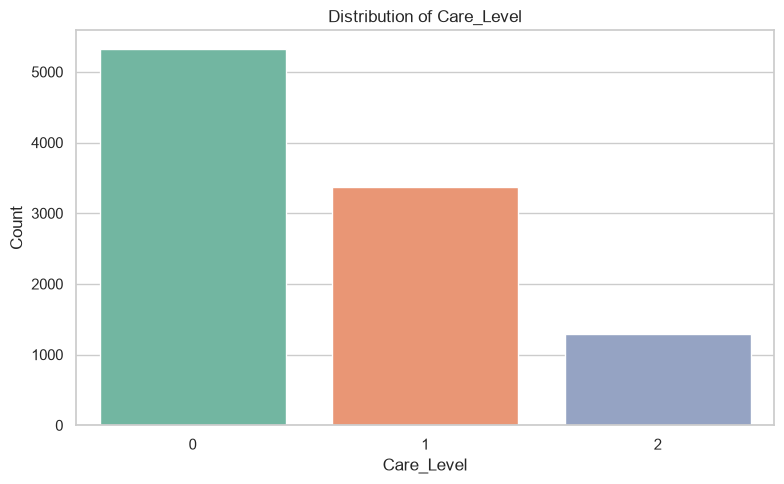

Care_Level
0    5320
1    3373
2    1296
Name: count, dtype: int64


In [7]:
# Phân bổ nhãn Care_Level
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

plt.figure(figsize=(8, 5))
order = sorted(df['Care_Level'].dropna().unique())
sns.countplot(data=df, x='Care_Level', order=order, hue='Care_Level', palette='Set2', legend=False)
plt.title('Distribution of Care_Level')
plt.xlabel('Care_Level')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

print(df['Care_Level'].value_counts(dropna=False).sort_index())

Features used for PCA: ['RAGENDER', 'R16AGEY_M', 'R16DRESS', 'R16BATH', 'R16EAT', 'R16BED', 'R16TOILT', 'R16PHONE', 'R16MONEY', 'R16MEDS', 'R16MEALS', 'R16SHOP', 'R16ADL5A', 'R16IADL5A']
Explained variance ratio: [0.33510027 0.10518535]


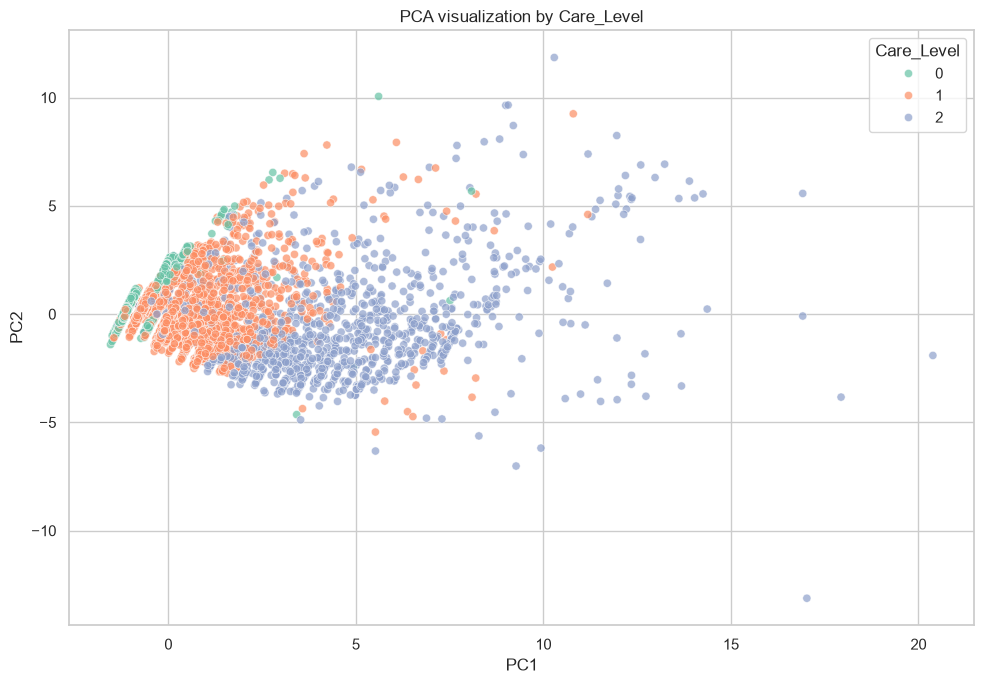

In [8]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Chọn các cột số có thể dùng cho PCA
candidate_features = [
    'RAGENDER', 'R16AGEY_M',
    'R16DRESS', 'R16BATH', 'R16EAT', 'R16BED', 'R16TOILT',
    'R16PHONE', 'R16MONEY', 'R16MEDS', 'R16MEALS', 'R16SHOP',
    'R16HLPDYST', 'R16HLPHRST',
    'R16ADL5A', 'R16IADL5A'
]
features = [col for col in candidate_features if col in df.columns]

if 'Care_Level' not in df.columns:
    raise KeyError("Không tìm thấy cột 'Care_Level' trong dữ liệu.")

pca_df = df[features + ['Care_Level']].copy()
pca_df = pca_df.dropna(subset=features + ['Care_Level'])

X = StandardScaler().fit_transform(pca_df[features])
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X)

pca_plot_df = pd.DataFrame({
    'PC1': coords[:, 0],
    'PC2': coords[:, 1],
    'Care_Level': pca_df['Care_Level'].astype(int).values,
})

print('Features used for PCA:', features)
print('Explained variance ratio:', pca.explained_variance_ratio_)

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=pca_plot_df,
    x='PC1',
    y='PC2',
    hue='Care_Level',
    palette='Set2',
    alpha=0.7,
    s=35
)
plt.title('PCA visualization by Care_Level')
plt.tight_layout()
plt.show()

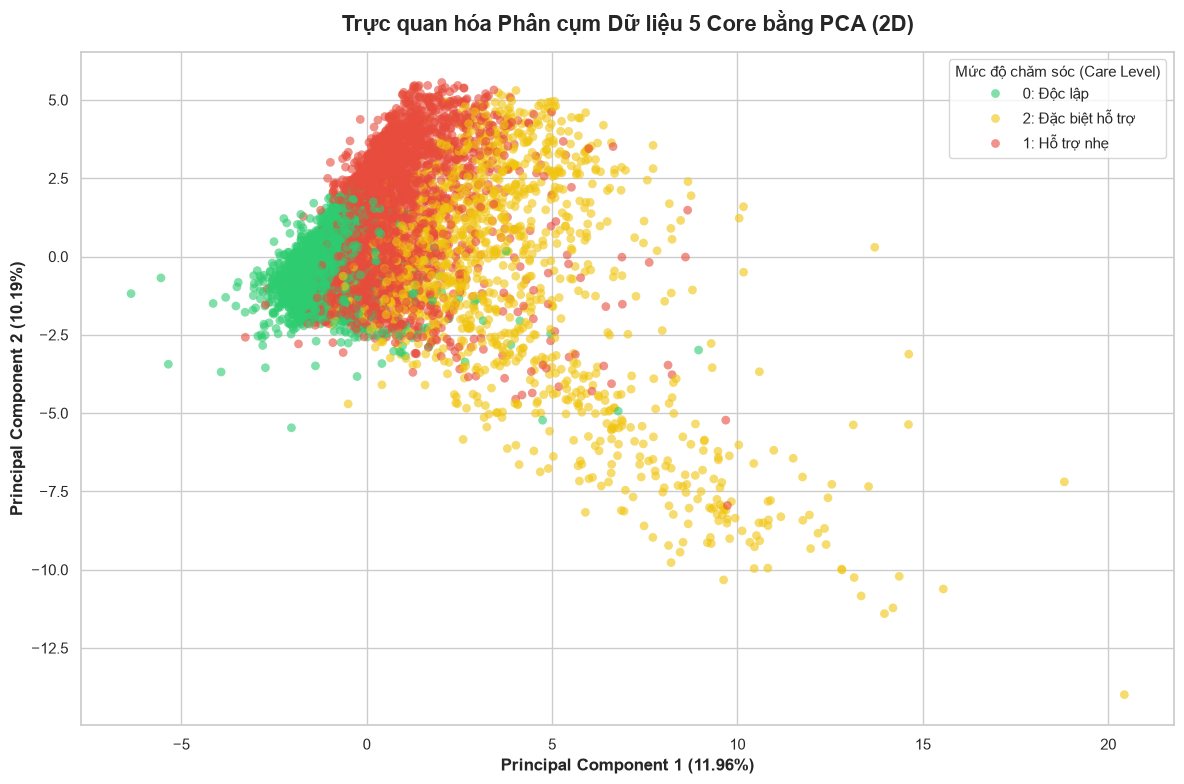

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. ĐỌC DỮ LIỆU ĐÃ LÀM SẠCH VÀ GÁN NHÃN 3 LỚP
file_path = r"D:\2026\MockProject_062026_NhomAI\data\filtered_5core_clean.csv"
df = pd.read_csv(file_path)

# 2. CHUẨN BỊ MA TRẬN TÍNH NĂNG (X) VÀ NHÃN (y)
# Bắt buộc loại bỏ các cột định danh và các biến tổng hợp trực tiếp tạo nhãn để tránh Overfitting/Leakage
exclude_cols = ['HHIDPN', 'Care_Level', 'R16ADL5A', 'R16IADL5A', 'R16CESD']
feature_cols = [col for col in df.columns if col not in exclude_cols]

X = df[feature_cols]
y = df['Care_Level']

# 3. CHUẨN HÓA DỮ LIỆU (Bắt buộc trước khi chạy PCA)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. THỰC THI PCA GIẢM XUỐNG 2 THÀNH PHẦN CHÍNH (2D)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Tạo DataFrame mới lưu tọa độ PCA và nhãn tương ứng
df_pca = pd.DataFrame(data=X_pca, columns=['Principal Component 1', 'Principal Component 2'])
df_pca['Care_Level'] = y.values

# Tính toán tỷ lệ phương sai giải thích được (Explained Variance Ratio)
var_pc1 = pca.explained_variance_ratio_[0] * 100
var_pc2 = pca.explained_variance_ratio_[1] * 100

# 5. VẼ ĐỒ THỊ TRỰC QUAN HÓA 2D SCATTER PLOT
plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid")

# Định nghĩa màu sắc và tên nhãn tường minh cho đồ thị
colors = {0: '#2ecc71', 1: '#f1c40f', 2: '#e74c3c'}
label_mapping = {0: '0: Độc lập', 1: '1: Hỗ trợ nhẹ', 2: '2: Đặc biệt hỗ trợ'}
df_pca['Care_Level_Label'] = df_pca['Care_Level'].map(label_mapping)

sns.scatterplot(
    x='Principal Component 1',
    y='Principal Component 2',
    hue='Care_Level_Label',
    palette=['#2ecc71', '#f1c40f', '#e74c3c'], # Xanh lá, Vàng, Đỏ
    data=df_pca,
    alpha=0.6,
    s=40,
    edgecolor='none'
)

# Cấu hình tiêu đề và nhãn trục hiển thị phần trăm phương sai giải thích được
plt.title('Trực quan hóa Phân cụm Dữ liệu 5 Core bằng PCA (2D)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel(f'Principal Component 1 ({var_pc1:.2f}%)', fontsize=12, fontweight='bold')
plt.ylabel(f'Principal Component 2 ({var_pc2:.2f}%)', fontsize=12, fontweight='bold')
plt.legend(title='Mức độ chăm sóc (Care Level)', title_fontsize='11', loc='upper right', frameon=True)

# Lưu đồ thị vào thư mục data của bạn
plt.tight_layout()
plt.savefig(r"D:\2026\MockProject_062026_NhomAI\data\pca_5core_visualization.png", dpi=300)
plt.show()

In [10]:
import json
from pathlib import Path
import pandas as pd

clean_path = Path(r"D:\2026\MockProject_062026_NhomAI\data\filtered_5core_clean.csv")
json_path = Path(r"D:\2026\MockProject_062026_NhomAI\data\filtered_5core_clean.json")

df = pd.read_csv(clean_path, low_memory=False)

if 'Care_Level' not in df.columns:
    raise KeyError("Không tìm thấy cột 'Care_Level' trong dữ liệu.")

feature_cols = [col for col in df.columns if col != 'Care_Level']

records = []
for _, row in df.iterrows():
    data_obj = {}
    for col in feature_cols:
        value = row[col]
        if pd.isna(value):
            data_obj[col] = None
        elif hasattr(value, 'item'):
            try:
                data_obj[col] = value.item()
            except Exception:
                data_obj[col] = value
        else:
            data_obj[col] = value

    care_level = row['Care_Level']
    if pd.isna(care_level):
        care_level_value = None
    elif hasattr(care_level, 'item'):
        try:
            care_level_value = care_level.item()
        except Exception:
            care_level_value = care_level
    else:
        care_level_value = care_level

    records.append({
        'Data': data_obj,
        'Care_Level': care_level_value
    })

with open(json_path, 'w', encoding='utf-8') as f:
    json.dump(records, f, ensure_ascii=False, indent=2)

print('Saved JSON to:', json_path)
print('Number of records:', len(records))
print('First record preview:')
print(json.dumps(records[0], ensure_ascii=False, indent=2)[:1200])

Saved JSON to: D:\2026\MockProject_062026_NhomAI\data\filtered_5core_clean.json
Number of records: 9989
First record preview:
{
  "Data": {
    "HHIDPN": 10001010.0,
    "RAGENDER": 1.0,
    "R16AGEY_M": 83.0,
    "R16DRESS": 0.0,
    "R16BATH": 0.0,
    "R16EAT": 0.0,
    "R16BED": 0.0,
    "R16TOILT": 0.0,
    "R16WALK1": 0.0,
    "R16PHONE": 0.0,
    "R16MONEY": 0.0,
    "R16MEDS": 0.0,
    "R16MEALS": 7.0,
    "R16SHOP": 0.0,
    "R16WANDER": 0.0,
    "R16LOST": 0.0,
    "R16HALUC": 0.0,
    "R16DEMEN": 0.0,
    "R16ALZHE": 0.0,
    "REBEDRID": 0.0,
    "R16STROK": 0.0,
    "R16SDAPNEA": 0.0,
    "R16TIMWLK": 3.53,
    "R16BALSEMI": 10.0,
    "R16BALFUL": 60.0,
    "R16DEPRES": 0.0,
    "R16EFFORT": 0.0,
    "R16SLEEPR": 1.0,
    "R16FLONE": 0.0,
    "R16FSAD": 0.0,
    "R16GOING": 0.0,
    "R16WHAPPY": 1.0,
    "R16ENLIFE": 1.0,
    "R16ADL5A": 0.0,
    "R16IADL5A": 0.0,
    "R16CESD": 1.0,
    "H16ATOTW": 1000300.0,
    "H16ITOT": 8400.0,
    "H16INPOV": 1.0,
    "R16IEARN": 0.0,

C:\Users\dattr\AppData\Local\Temp\ipykernel_17676\2057639910.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_features.values, y=top_features.index, palette='viridis')


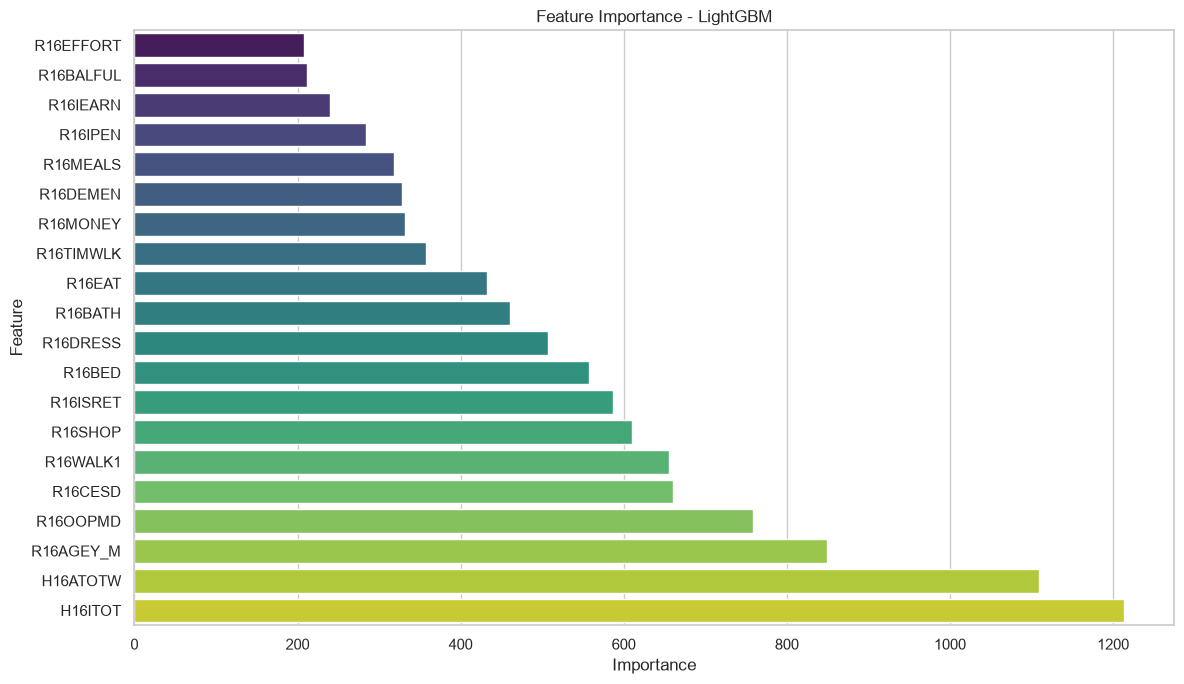

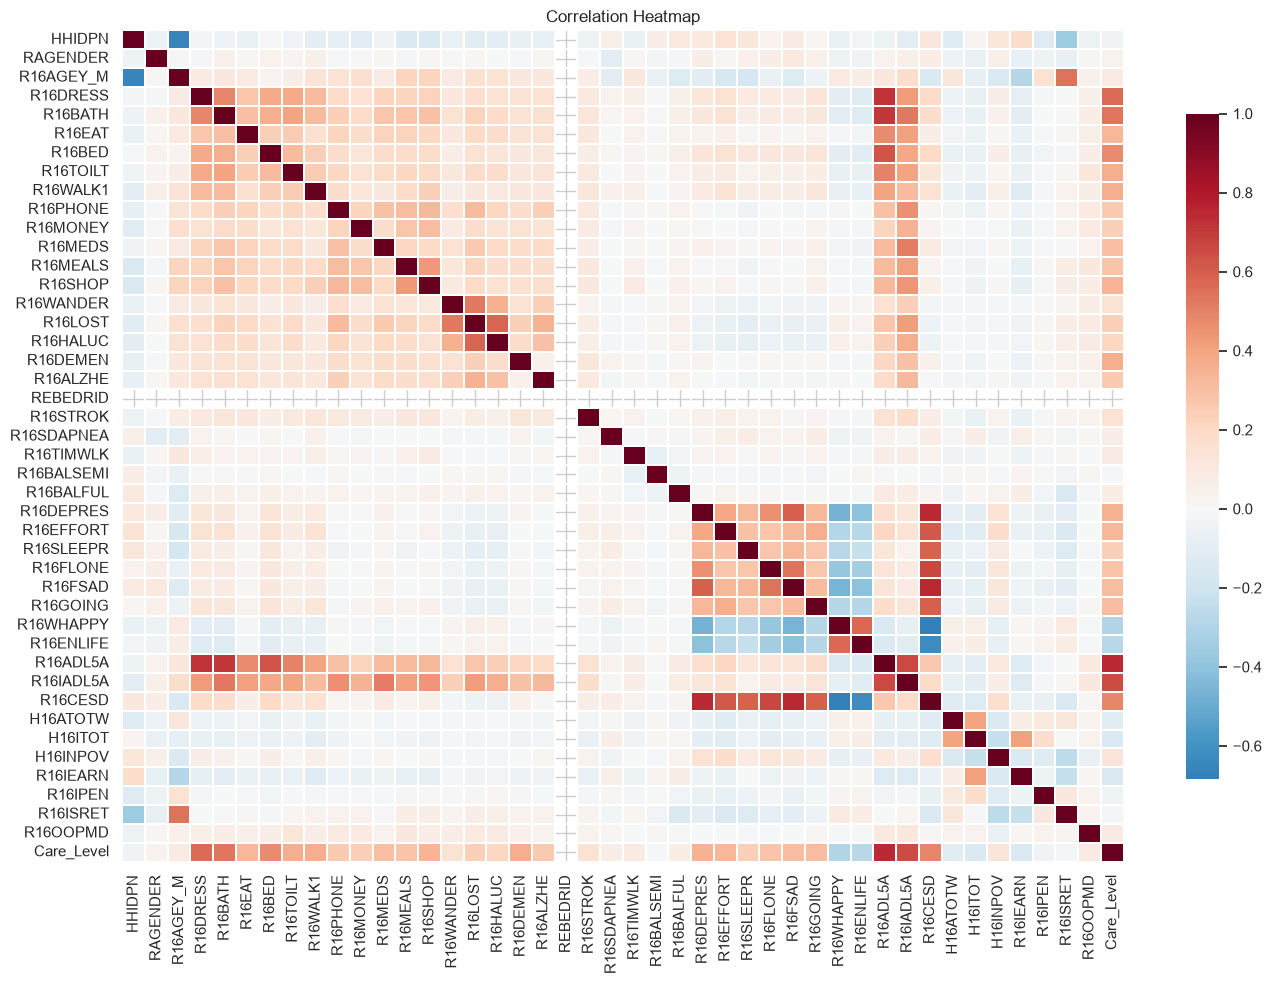

In [11]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid')

base_dir = Path(r"D:\2026\MockProject_062026_NhomAI")
clean_path = base_dir / "data" / "filtered_5core_clean.csv"
model_candidates = [
    base_dir / "model" / "lightgbm_flat_pipeline.pkl",
    base_dir / "model" / "xgboost_flat_pipeline.pkl",
    base_dir / "model" / "random_forest_flat_pipeline.pkl",
]

model_path = next((path for path in model_candidates if path.exists()), None)
if model_path is None:
    raise FileNotFoundError("Không tìm thấy file model phù hợp trong thư mục model/.")

pipeline_data = joblib.load(model_path)
model = pipeline_data.get('model')
feature_names = pipeline_data.get('features')

if feature_names is None:
    raise KeyError("File model không chứa danh sách feature_names.")
if not hasattr(model, 'feature_importances_'):
    raise AttributeError(f"Mô hình '{pipeline_data.get('model_name', model_path.stem)}' không hỗ trợ feature_importances_.")

feature_importance = pd.Series(model.feature_importances_, index=feature_names).sort_values(ascending=False)
top_n = min(20, len(feature_importance))
top_features = feature_importance.head(top_n).sort_values()

plt.figure(figsize=(12, max(6, top_n * 0.35)))
sns.barplot(x=top_features.values, y=top_features.index, palette='viridis')
plt.title(f"Feature Importance - {pipeline_data.get('model_name', model_path.stem)}")
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

if not clean_path.exists():
    raise FileNotFoundError(f"Không tìm thấy file dữ liệu sạch: {clean_path}")

df = pd.read_csv(clean_path, low_memory=False)
if 'Care_Level' not in df.columns:
    raise KeyError("Không tìm thấy cột 'Care_Level' trong dữ liệu sạch.")

numeric_df = df.select_dtypes(include=[np.number]).copy()
if numeric_df.shape[1] < 2:
    raise ValueError('Không đủ cột số để vẽ heatmap tương quan.')

corr = numeric_df.corr(numeric_only=True)
plt.figure(figsize=(14, 10))
sns.heatmap(corr, cmap='RdBu_r', center=0, linewidths=0.25, cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import json
import numpy as np

# Hàm hỗ trợ chuyển đổi kiểu dữ liệu Numpy sang kiểu dữ liệu chuẩn của Python để lưu JSON
def safe_val(val):
    if pd.isna(val):
        return None
    if isinstance(val, (np.int64, np.int32)):
        return int(val)
    if isinstance(val, (np.float64, np.float32)):
        return float(val)
    return val

# 2. Hàm ánh xạ từng dòng dữ liệu thành dictionary theo cấu trúc Template
def row_to_json(row):
    return {
        "5 cores": {
            "ADLs & IADLs": {
                "R16DRESS": safe_val(row.get('R16DRESS')),
                "R16BATH": safe_val(row.get('R16BATH')),
                "R16EAT": safe_val(row.get('R16EAT')),
                "R16BED": safe_val(row.get('R16BED')),
                "R16TOILT": safe_val(row.get('R16TOILT')),
                "R16WALK1": safe_val(row.get('R16WALK1')),
                "R16PHONE": safe_val(row.get('R16PHONE')),
                "R16MONEY": safe_val(row.get('R16MONEY')),
                "R16MEDS": safe_val(row.get('R16MEDS')),
                "R16MEALS": safe_val(row.get('R16MEALS')),
                "R16SHOP": safe_val(row.get('R16SHOP')),
                "R16ADL5A": safe_val(row.get('R16ADL5A')),    # Biến tổng hợp ADL
                "R16IADL5A": safe_val(row.get('R16IADL5A')),  # Biến tổng hợp IADL
                "R16AGEY_M": safe_val(row.get('R16AGEY_M'))
            },
            "Cognitive & Neurological Status": {
                "R16WANDER": safe_val(row.get('R16WANDER')),
                "R16LOST": safe_val(row.get('R16LOST')),
                "R16HALUC": safe_val(row.get('R16HALUC')),
                "R16DEMEN": safe_val(row.get('R16DEMEN')),
                "R16ALZHE": safe_val(row.get('R16ALZHE'))
            },
            "Clinical Risk Assessments": {
                "REBEDRID": safe_val(row.get('REBEDRID')),
                "R16STROK": safe_val(row.get('R16STROK')),
                "R16SDAPNEA": safe_val(row.get('R16SDAPNEA')),
                "R16TIMWLK": safe_val(row.get('R16TIMWLK')),
                "R16BALSEMI": safe_val(row.get('R16BALSEMI')),
                "R16BALFUL": safe_val(row.get('R16BALFUL'))
            },
            "Mood & Behavioral Health": {
                "R16DEPRES": safe_val(row.get('R16DEPRES')),
                "R16EFFORT": safe_val(row.get('R16EFFORT')),
                "R16SLEEPR": safe_val(row.get('R16SLEEPR')),
                "R16FLONE": safe_val(row.get('R16FLONE')),
                "R16FSAD": safe_val(row.get('R16FSAD')),
                "R16GOING": safe_val(row.get('R16GOING')),
                "R16WHAPPY": safe_val(row.get('R16WHAPPY')),
                "R16ENLIFE": safe_val(row.get('R16ENLIFE')),
                "R16CESD": safe_val(row.get('R16CESD'))      # Điểm trầm cảm tổng hợp
            },
            "Financial & Legal": {
                "H16ATOTW": safe_val(row.get('H16ATOTW')),
                "H16ITOT": safe_val(row.get('H16ITOT')),
                "H16INPOV": safe_val(row.get('H16INPOV')),
                "R16IEARN": safe_val(row.get('R16IEARN')),
                "R16IPEN": safe_val(row.get('R16IPEN')),
                "R16ISRET": safe_val(row.get('R16ISRET')),
                "R16OOPMD": safe_val(row.get('R16OOPMD'))
            }
        },
        "Care_Level": safe_val(row.get('Care_Level'))
    }

# 3. Tạo mảng chứa toàn bộ dữ liệu dưới dạng JSON
json_dataset = [row_to_json(row) for index, row in df_clean.iterrows()]

# 4. Xuất ra tệp JSON hoàn chỉnh
output_json_path = r"D:\2026\MockProject_062026_NhomAI\data\dataset_5core_template.json"
with open(output_json_path, 'w', encoding='utf-8') as json_file:
    # indent=4 giúp định dạng file JSON đẹp, dễ đọc; ensure_ascii=False hỗ trợ chuẩn UTF-8 nếu có ký tự đặc biệt
    json.dump(json_dataset, json_file, indent=4, ensure_ascii=False)

print(f"[THÀNH CÔNG] Đã chuyển đổi {len(json_dataset)} bản ghi sang định dạng JSON và lưu tại: {output_json_path}")

[THÀNH CÔNG] Đã chuyển đổi 9989 bản ghi sang định dạng JSON và lưu tại: D:\2026\MockProject_062026_NhomAI\data\dataset_5core_template.json
